In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import uproot

In [3]:
from res_map_v2 import d0_eta_bins, d0_pt_bins_charged, d0_pt_bins_muons, d0_funclist_charged, d0_funclist_muons

In [4]:
def load_data(path):
    """
    Load data from a ROOT file.
    """
    data = {}
    with uproot.open(path) as f:
        pfcs = f['pfcs/Events'].arrays(library='np')
        data = {}
        for branch in pfcs:
            try:
                data[branch] = np.concatenate(pfcs[branch])
            except ValueError:
                data[branch] = pfcs[branch]
        mask = (data['PFCand_d0'] != -1000) & (np.abs(data['PFCand_eta']) < 2.5) & (data['PFCand_pt'] > 1)
    data['mask'] = mask
    return data

In [59]:
samples_dict = {
    # 'zzto4mu' : load_data('zzto4mu_test.root'),
    # 'ttbar' : load_data('ttbar_test.root'),
    'ttbar' : load_data('/storage/agrp/dmitrykl/fastsim/f_delphes/data/full_event/raw_impact/MonteCarlo2011/Summer11LegDR/TTJets_MSDecays_central_TuneZ2_7TeV-madgraph-tauola/AODSIM/PU_S13_START53_LV6-v1/00000/000F3C2D-E7BA-E311-88FF-90E6BA0D09E8_poet.root'),
    # "vbfh4lep" : load_data('vbfh4lep_test.root'),
}

In [60]:
x = np.random.rand(5, 2) * 2

In [61]:
def get_d0Error(pt, eta, d0_pt_bins, d0_funclist):
    error = 0
    for i, (left_eta, right_eta) in enumerate(zip(d0_eta_bins[:-1], d0_eta_bins[1:])):
        for j, (left_pt, right_pt) in enumerate(zip(d0_pt_bins[:-1], d0_pt_bins[1:])):
            error += (np.abs(eta) >= left_eta) * (np.abs(eta) < right_eta) * \
                    (pt >= left_pt) * (pt < right_pt) * \
                    d0_funclist[i * (len(d0_pt_bins) - 1) + j]
    return error

In [62]:
for sample in samples_dict:
    data = samples_dict[sample]
    # mask = data['mask']
    # x = np.stack((data['PFCand_eta'][mask], data['PFCand_pt'][mask]), axis=1)
    # x= np.stack((data['PFCand_eta'], data['PFCand_pt']), axis=1)
    # d0Error = np.piecewise(
    #     x,
    #     condlist=[f(x) for f in d0_condlist],
    #     funclist=d0_funclist / 10,
    # )[..., 0]
    muons_mask = np.abs(data['PFCand_pdgId']) == 13
    d0Error_muons = get_d0Error(data['PFCand_pt'][muons_mask], data['PFCand_eta'][muons_mask], d0_pt_bins_muons, d0_funclist_muons) / 10
    d0Error_charged = get_d0Error(data['PFCand_pt'][~muons_mask], data['PFCand_eta'][~muons_mask], d0_pt_bins_charged, d0_funclist_charged) / 10 / 1e3
    d0Error = np.zeros_like(data['PFCand_pt'])
    d0Error[muons_mask] = d0Error_muons
    d0Error[~muons_mask] = d0Error_charged
    data['PFCand_d0ErrorMy'] = d0Error


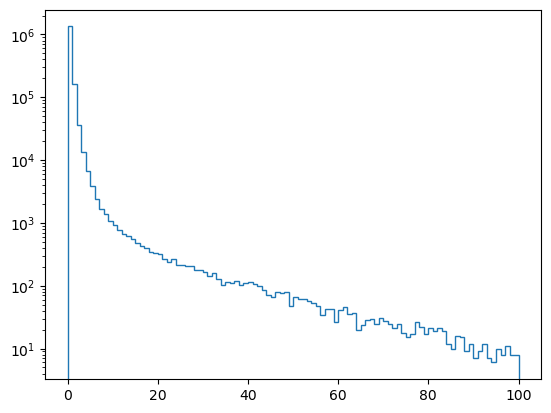

In [12]:
plt.hist(data['PFCand_pt'], bins=100, range=(0, 100), histtype='step', label='pt')
plt.yscale('log')

Text(0, 0.5, 'Counts')

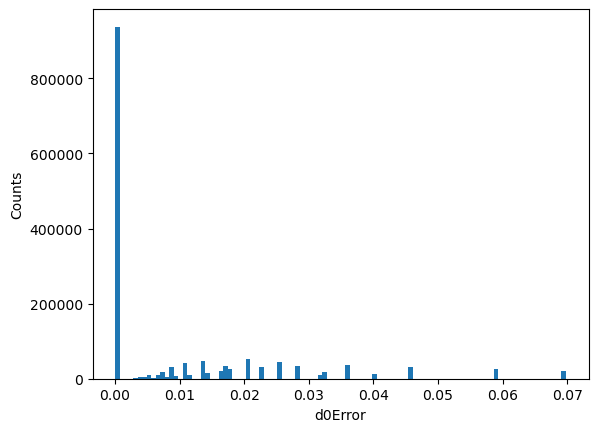

In [13]:
plt.hist(
    samples_dict['zzto4mu']['PFCand_d0ErrorMy'],
    bins=100,
)
plt.xlabel('d0Error')
plt.ylabel('Counts')

In [66]:
def plot_ip_params(samples_dict: dict):
    fig, ax = plt.subplots(3, 3, figsize=(15, 10))
    bins = {
        'd0' : [
            np.linspace(-0.02, 0.02, 100),
            np.linspace(-0.1, 0.3, 100),
            np.linspace(-4, 4, 100),
        ],
        'z0' : [
            np.linspace(-0.02, 0.02, 100),
            np.linspace(-0.1, 0.3, 100),
            np.linspace(-4, 4, 100),
        ],
        'ip3d' : [
            np.linspace(0, 0.25, 100),
            np.linspace(0, 4, 100),
            np.linspace(0, 0.5, 100),
        ],
    }
    labels = ['d0', 'z0', 'ip3d']
    for i, label in enumerate(labels):
        for key, data in samples_dict.items():
            mask = data['mask']
            ax[0, i].hist(data[f"PFCand_{label}"][mask], label=key, histtype='step', density=True, bins=bins[label][0])
            ax[1, i].hist(data[f"PFCand_{label}Error"][mask], label=key, histtype='step', density=True, bins=bins[label][1])
            if label == 'd0':
                ax[1, i].hist(data[f"PFCand_{label}ErrorMy"], label=key + 'My', histtype='step', density=True, bins=bins[label][1])
                ax[2, i].hist((data[f"PFCand_{label}"] / data[f"PFCand_{label}ErrorMy"])[mask], label=key + 'My', histtype='step', density=True, bins=bins[label][2])
            ax[2, i].hist((data[f"PFCand_{label}"] / data[f"PFCand_{label}Error"])[mask], label=key, histtype='step', density=True, bins=bins[label][2])
        ax[0, i].set_title(label)
        ax[1, i].set_title(label + "Error")
        ax[2, i].set_title(label + " / " + label + "Error")
        for j in range(3):
            ax[j, i].legend()
            ax[j, i].set_xlabel(label)
            ax[j, i].set_ylabel('Density')
            ax[j, i].grid()
    fig.tight_layout()
    fig.show()

/tmp/ipykernel_162990/2115312523.py:28: RuntimeWarning: divide by zero encountered in divide
  ax[2, i].hist((data[f"PFCand_{label}"] / data[f"PFCand_{label}ErrorMy"])[mask], label=key + 'My', histtype='step', density=True, bins=bins[label][2])


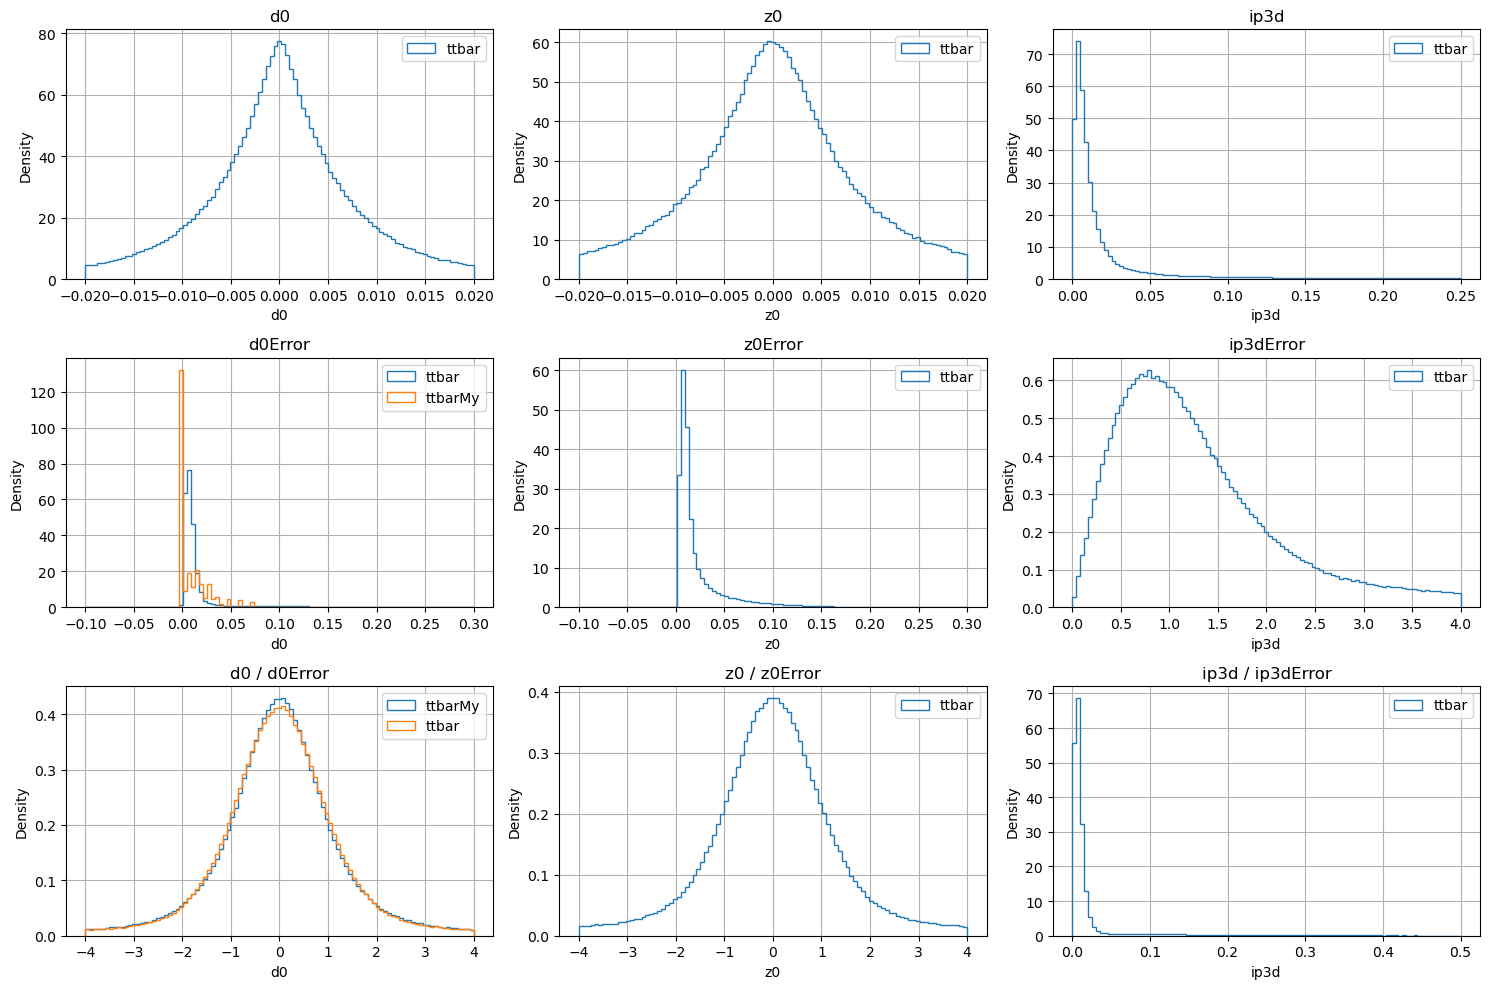

In [67]:
plot_ip_params(samples_dict)

In [68]:
mask_mu = np.abs(samples_dict['zzto4mu']['PFCand_pdgId']) == 13

KeyError: 'zzto4mu'

In [69]:
for sample, value in samples_dict.items():
    value['d0Sig'] = np.abs(np.abs(value['PFCand_d0'] / value['PFCand_d0Error']))
    value['d0SigMy'] = np.abs(np.abs(value['PFCand_d0'] / value['PFCand_d0ErrorMy']))

/tmp/ipykernel_162990/3637877198.py:3: RuntimeWarning: divide by zero encountered in divide
  value['d0SigMy'] = np.abs(np.abs(value['PFCand_d0'] / value['PFCand_d0ErrorMy']))


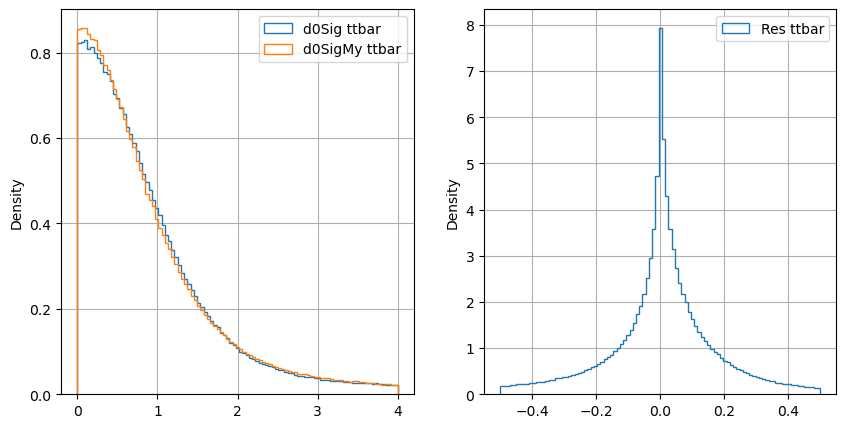

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
for sample, value in samples_dict.items():
    for key in ['d0Sig', 'd0SigMy']:
        ax[0].hist(
            value[key][value['mask']],
            bins=np.linspace(0, 4, 100),
            label=key + ' ' + sample,
            histtype='step',
            density=True,
        )
    ax[1].hist(
        (value['d0Sig'] - value['d0SigMy'])[value['mask']],
        bins=np.linspace(-0.5, 0.5, 100),
        label="Res " + sample,
        histtype='step',
        density=True,
    )
for i in range(2):
    ax[i].set_ylabel('Density')
    ax[i].legend()
    ax[i].grid()
    # ax[i].set_yscale('log')
plt.show()